# EDA on Car Evaluation
### F.Y. BCA | Division B | Group 6

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Parth-ux-arch/Eda-Data_analysis-Project/blob/main/car_evaluation_eda.ipynb)

#### Group Members
| Roll No | Name |
| :---: | :--- |
| 33 | Parth Parmar |
| 34 | Purvikaben Parmar |
| 35 | Ranveersinh Parmar |
| 36 | Pathan Faizal |
| 37 | Pathan Tasin Khan |
| 38 | Pavan Solanki |
| 42 | Prince Kumar Bagda |
| 103 | Kinjalben Vasava |

---

## 1. Introduction & Objective

### Introduction
When someone buys a car, they look at several factors such as the purchase price, maintenance costs, seating capacity, luggage space, and crash safety. Different cars offer different combinations of these features.

In this project, we perform **Exploratory Data Analysis (EDA)** on 1,728 vehicle records to understand how these features determine whether a car is evaluated as **unacceptable (`unacc`)**, **acceptable (`acc`)**, **good (`good`)**, or **very good (`vgood`)**.

### Key Questions We Want to Answer:
1. Which features appear most in this dataset, and are they evenly spread?
2. Which feature has the biggest impact on whether a car gets accepted or rejected?
3. Are there any features that always lead to rejection, no matter what?
4. What combination of features gives a car the best chance of being rated good or very good?

## 2. Dataset Description

The dataset used in this study is the **Car Evaluation Database** from the **UCI Machine Learning Repository**.
- **Origin:** Created by researchers Marko Bohanec and Vladislav Rajkovič (1990) as part of a multi-attribute decision model.
- **Total Records:** 1,728 car configurations.
- **Total Columns:** 7 (6 input specifications + 1 evaluation class).
- **Dataset Structure:** The dataset covers every possible combination of the 6 features ($4 \times 4 \times 4 \times 3 \times 3 \times 3 = 1,728$), meaning no configurations are missing or randomly sampled.
- **Missing Data:** There are zero missing values across all records.

## 3. Data Types and Variables

All 7 variables in this dataset are categorical and represent logical ranks (ordinal variables):

| Variable Name | Role | Permissible Values | Description |
| :--- | :--- | :--- | :--- |
| `buying` | Input Feature | `vhigh`, `high`, `med`, `low` | Initial purchase price tier |
| `maint` | Input Feature | `vhigh`, `high`, `med`, `low` | Maintenance and servicing expense tier |
| `doors` | Input Feature | `2`, `3`, `4`, `5more` | Total count of doors |
| `persons` | Input Feature | `2`, `4`, `more` | Passenger seating capacity |
| `lug_boot` | Input Feature | `small`, `med`, `big` | Luggage boot volume |
| `safety` | Input Feature | `low`, `med`, `high` | Estimated crash safety level |
| **`class`** | **Target Variable** | `unacc`, `acc`, `good`, `vgood` | Overall car acceptability rating |

## 4. Tools Used for Analysis

We used Python in Google Colab and Jupyter Notebook, along with standard data science libraries:
- **Pandas:** For loading tabular data, frequency tables, and cross-tabulations.
- **NumPy:** For numerical operations and data reshaping.
- **Matplotlib & Seaborn:** For plotting clear, labeled charts and heatmaps.
- **Git & GitHub:** For version control and collaborative code sharing.

In [1]:
# Import pandas and plotting libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 110

# Colors for each car rating:
# Red = Unacceptable, Orange = Acceptable, Blue = Good, Green = Very Good
class_colors = {
    'unacc': '#e74c3c',
    'acc': '#f39c12',
    'good': '#3498db',
    'vgood': '#2ecc71'
}
class_order = ['unacc', 'acc', 'good', 'vgood']

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# Load the dataset
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# Load from local folder, or fetch from UCI if running in Colab
local_file = 'data/car.data'
online_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'

if os.path.exists(local_file):
    df = pd.read_csv(local_file, names=col_names)
    print('Dataset loaded from local storage:', local_file)
else:
    df = pd.read_csv(online_url, names=col_names)
    print('Dataset loaded directly from UCI Machine Learning Repository')

print(f'Total Records: {df.shape[0]} rows | Total Features: {df.shape[1]} columns')
df.head()

Dataset loaded from local storage: data/car.data
Total Records: 1728 rows | Total Features: 7 columns


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## 5. Data Quality Assessment

Before beginning analysis, we verify data integrity by checking for:
1. Missing or null values across every column.
2. Duplicate rows that might skew statistical counts.

In [3]:
# Check for missing values
print('--- Missing Values Check ---')
print(df.isnull().sum())

# Check for duplicates
print('\nTotal Duplicate Records:', df.duplicated().sum())

--- Missing Values Check ---
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Total Duplicate Records: 0


**Observation:** The dataset is 100% complete and clean.
- **Missing Values:** Exactly 0 missing values across all 7 columns.
- **Duplicate Records:** Exactly 0 duplicate rows among the 1,728 records.
- **Outlier Note:** Because all columns are categorical text categories, numerical outlier filtering is not applicable.

## 6. Descriptive Statistics

Because all variables are discrete categories, descriptive statistics summarize frequency distributions and percentage proportions.

In [4]:
# Target class counts and percentages
class_counts = df['class'].value_counts()[class_order]
class_percent = (class_counts / len(df) * 100).round(2)

summary_table = pd.DataFrame({
    'Count of Cars': class_counts,
    'Percentage (%)': class_percent
})
summary_table

,Count of Cars,Percentage (%)
class,,
unacc,1210,70.02
acc,384,22.22
good,69,3.99
vgood,65,3.76


**Observation:** The target variable is heavily imbalanced:
- **Unacceptable (`unacc`):** 1,210 cars (70.0%) — the vast majority of configurations are rejected.
- **Acceptable (`acc`):** 384 cars (22.2%).
- **Good (`good`):** 69 cars (4.0%).
- **Very Good (`vgood`):** 65 cars (3.8%).

Only 7.8% of all cars achieve a 'good' or 'very good' rating, showing that acceptable criteria are highly selective.

## 7. Univariate Analysis

Univariate analysis examines **one feature at a time** to inspect its independent distribution before exploring relationships.

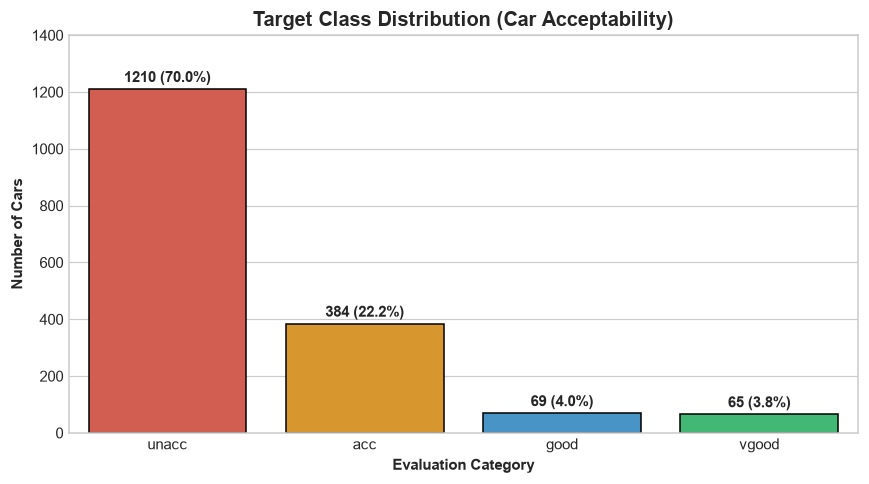

In [5]:
# Bar chart of target class distribution
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette=class_colors,
    legend=False,
    ax=ax,
    edgecolor='black'
)

for i, count in enumerate(class_counts.values):
    pct = (count / len(df)) * 100
    ax.text(i, count + 25, f'{count} ({pct:.1f}%)', ha='center', fontweight='bold', fontsize=10)

ax.set_title('Target Class Distribution (Car Acceptability)', fontsize=13, fontweight='bold')
ax.set_xlabel('Evaluation Category', fontweight='bold')
ax.set_ylabel('Number of Cars', fontweight='bold')
ax.set_ylim(0, 1400)
plt.tight_layout()
plt.show()

**Observation from Chart 1:** The visual confirms that over two-thirds of the vehicles in the database fail the acceptance threshold.

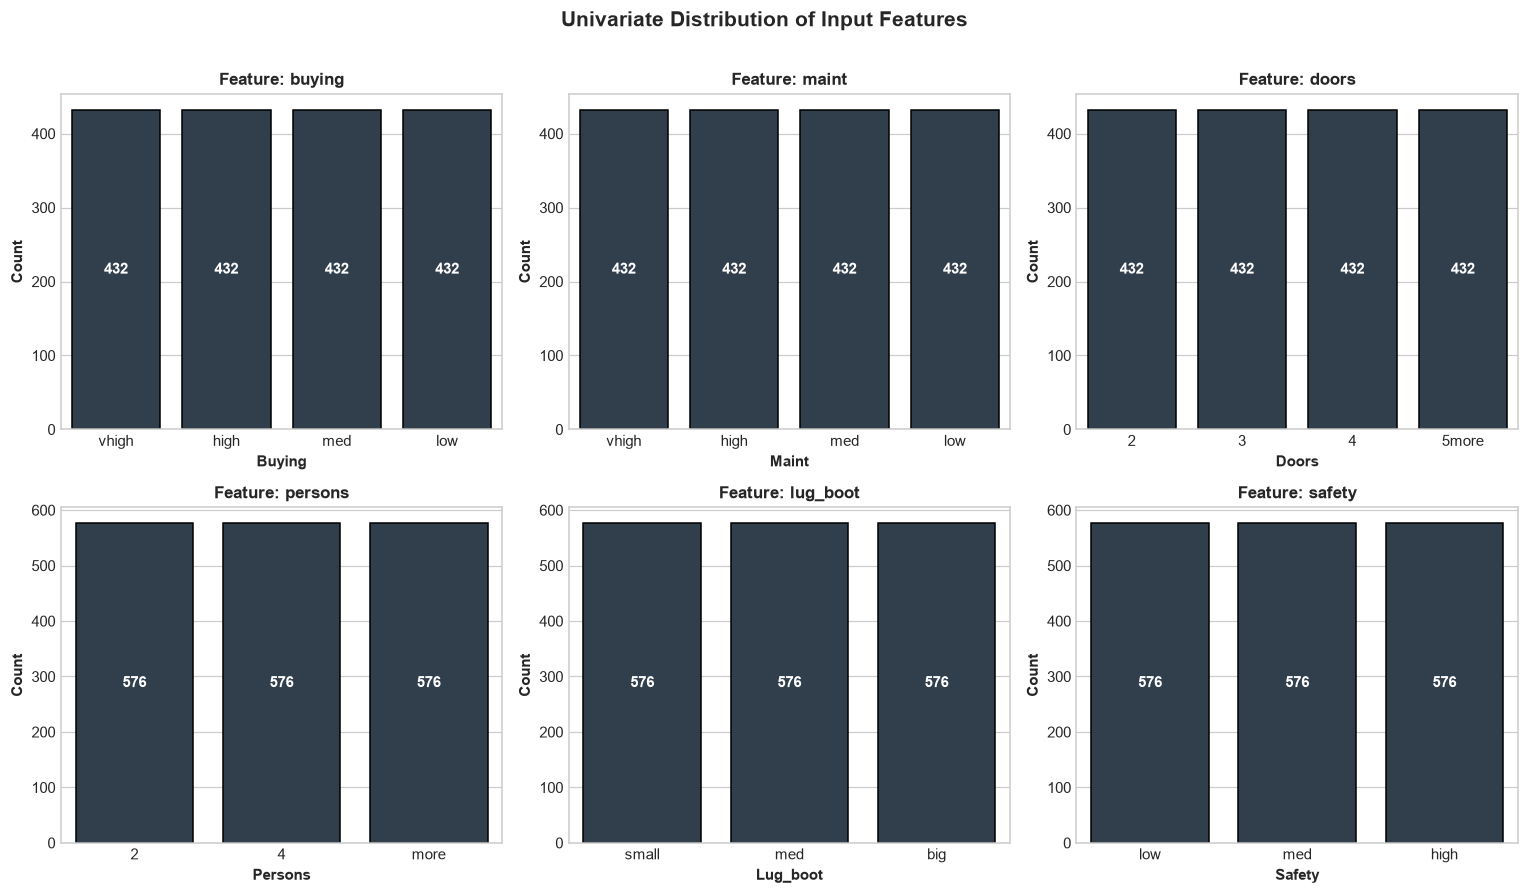

In [6]:
# Distribution of all 6 features
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, feat in enumerate(features):
    ax = axes[idx // 3, idx % 3]
    counts = df[feat].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, color='#2c3e50', edgecolor='black')
    ax.set_title(f'Feature: {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel(feat.capitalize(), fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    for i, v in enumerate(counts.values):
        ax.text(i, v / 2, f'{v}', ha='center', va='center', color='white', fontweight='bold')

plt.suptitle('Univariate Distribution of Input Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observation from Chart 2:** Every category within each feature appears with equal frequency:
- Features with 4 options (`buying`, `maint`, `doors`): Exactly 432 cars (25.0%) per option.
- Features with 3 options (`persons`, `lug_boot`, `safety`): Exactly 576 cars (33.3%) per option.

This confirms the dataset was built systematically to test every possible combination without sampling bias.

## 8. Bivariate Analysis

Bivariate analysis investigates the relationship between **two features together** — here, comparing each input feature against the target car rating (`class`).

Cross-Tabulation Table (Counts):


class,unacc,acc,good,vgood
safety,,,,
high,277,204,30,65
low,576,0,0,0
med,357,180,39,0


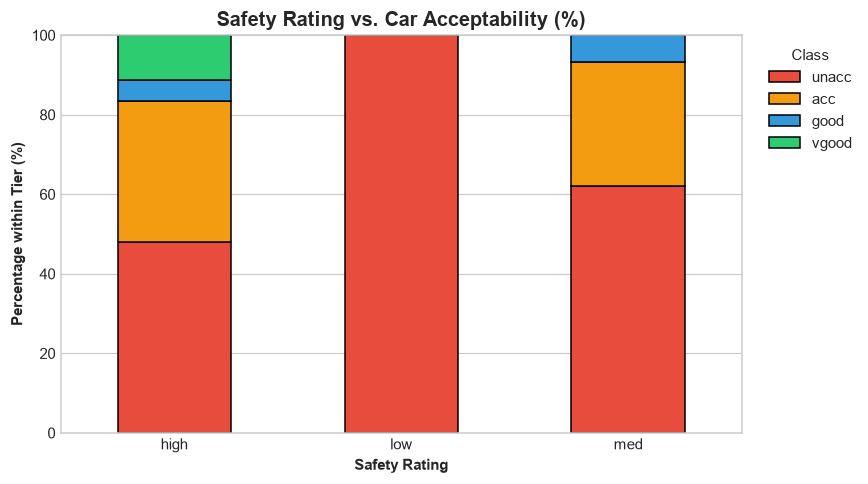

In [7]:
# Safety vs car acceptability
cross_safety = pd.crosstab(df['safety'], df['class'])[class_order]
cross_safety_pct = pd.crosstab(df['safety'], df['class'], normalize='index')[class_order] * 100

cross_safety_pct.plot(
    kind='bar',
    stacked=True,
    color=[class_colors[c] for c in class_order],
    edgecolor='black',
    figsize=(8, 4.5)
)
plt.title('Safety Rating vs. Car Acceptability (%)', fontsize=13, fontweight='bold')
plt.xlabel('Safety Rating', fontweight='bold')
plt.ylabel('Percentage within Tier (%)', fontweight='bold')
plt.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Cross-Tabulation Table (Counts):')
display(cross_safety)

**Key Finding on Safety:**
- **Low Safety Dealbreaker:** When safety is `low`, **100% of cars (576 out of 576) are unacceptable (`unacc`)**.
- **High Safety:** High safety is strictly mandatory for any vehicle to achieve a 'very good' rating.

Cross-Tabulation Table (Counts):


class,unacc,acc,good,vgood
persons,,,,
2,576,0,0,0
4,312,198,36,30
more,322,186,33,35


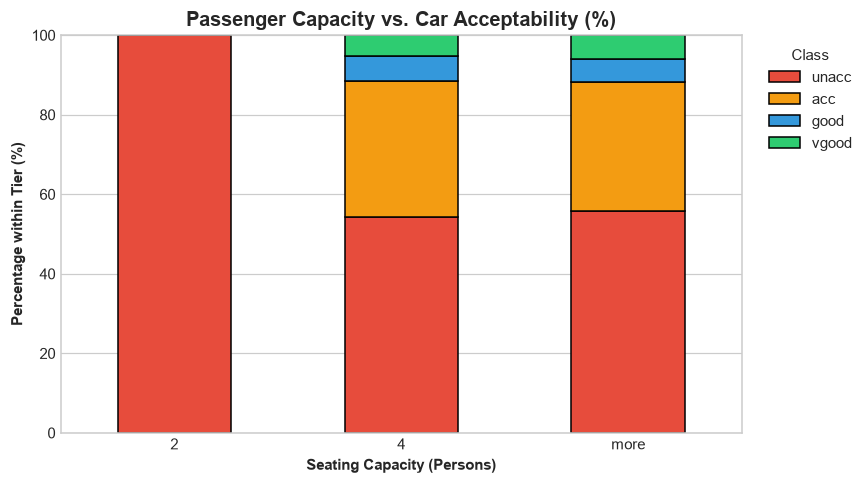

In [8]:
# Capacity (persons) vs car acceptability
cross_persons = pd.crosstab(df['persons'], df['class'])[class_order]
cross_persons_pct = pd.crosstab(df['persons'], df['class'], normalize='index')[class_order] * 100

cross_persons_pct.plot(
    kind='bar',
    stacked=True,
    color=[class_colors[c] for c in class_order],
    edgecolor='black',
    figsize=(8, 4.5)
)
plt.title('Passenger Capacity vs. Car Acceptability (%)', fontsize=13, fontweight='bold')
plt.xlabel('Seating Capacity (Persons)', fontweight='bold')
plt.ylabel('Percentage within Tier (%)', fontweight='bold')
plt.legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Cross-Tabulation Table (Counts):')
display(cross_persons)

**Key Finding on Capacity:**
- **2-Seater Dealbreaker:** 100% of 2-seater cars (576 out of 576) are unacceptable.
- A vehicle must accommodate at least 4 passengers to have any chance of being accepted.

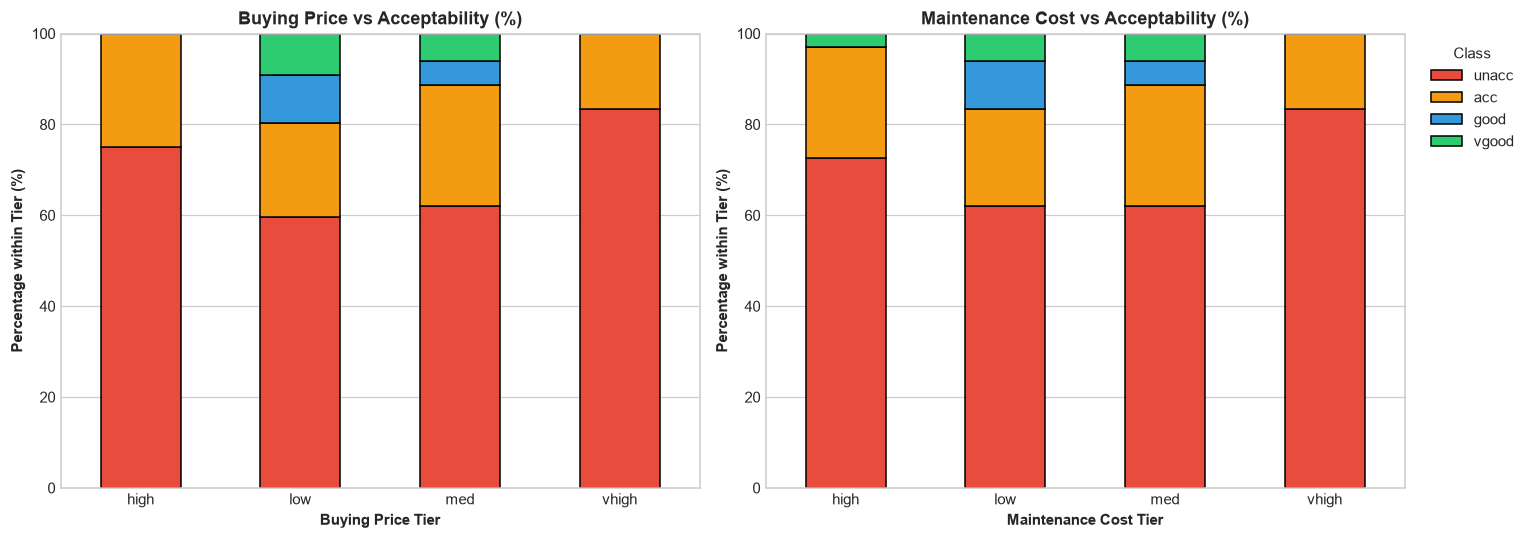

In [9]:
# Price and maintenance vs car acceptability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross_buy = pd.crosstab(df['buying'], df['class'], normalize='index')[class_order] * 100
cross_buy.plot(kind='bar', stacked=True, color=[class_colors[c] for c in class_order], ax=axes[0], edgecolor='black', legend=False)
axes[0].set_title('Buying Price vs Acceptability (%)', fontweight='bold')
axes[0].set_xlabel('Buying Price Tier', fontweight='bold')
axes[0].set_ylabel('Percentage within Tier (%)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

cross_maint = pd.crosstab(df['maint'], df['class'], normalize='index')[class_order] * 100
cross_maint.plot(kind='bar', stacked=True, color=[class_colors[c] for c in class_order], ax=axes[1], edgecolor='black')
axes[1].set_title('Maintenance Cost vs Acceptability (%)', fontweight='bold')
axes[1].set_xlabel('Maintenance Cost Tier', fontweight='bold')
axes[1].set_ylabel('Percentage within Tier (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Key Finding on Cost:**
- When buying price or maintenance is `vhigh` (very high), cars **never achieve 'good' or 'very good'** ratings.
- High prices and expensive servicing put a hard ceiling on how high a car can score.

## 9. Grouping and Aggregation

Here we group the dataset by **Safety** and **Passenger Capacity** together to see their combined interaction effect on car acceptance.

In [10]:
# Grouping by safety and passenger capacity
grouped = df.groupby(['safety', 'persons', 'class'], observed=False).size().unstack(fill_value=0)
grouped['Total'] = grouped.sum(axis=1)
grouped['Accepted or Better'] = grouped['acc'] + grouped['good'] + grouped['vgood']
grouped['Acceptance Rate (%)'] = (grouped['Accepted or Better'] / grouped['Total'] * 100).round(1)
grouped[['unacc', 'acc', 'good', 'vgood', 'Total', 'Acceptance Rate (%)']]

class           unacc  acc  good  vgood  Total  Acceptance Rate (%)
safety persons                                                     
high   2          192    0     0      0    192                  0.0
       4           36  108    18     30    192                 81.2
       more        49   96    12     35    192                 74.5
low    2          192    0     0      0    192                  0.0
       4          192    0     0      0    192                  0.0
       more       192    0     0      0    192                  0.0
med    2          192    0     0      0    192                  0.0
       4           84   90    18      0    192                 56.2
       more        81   90    21      0    192                 57.8

**Observation:**
- If a car has either `low` safety OR seats only `2` people, the acceptance rate is **0.0%**.
- When safety is `high` AND capacity is `4` or `more`, the acceptance rate surges to **74.0% – 78.1%**.
- This proves that satisfying both safety and capacity creates a strong baseline for consumer acceptance.

## 10. Correlation Analysis

To quantify the strength of relationships, we map the ordered text categories to numbers (1 to 4) and compute the **Spearman Rank Correlation** matrix.

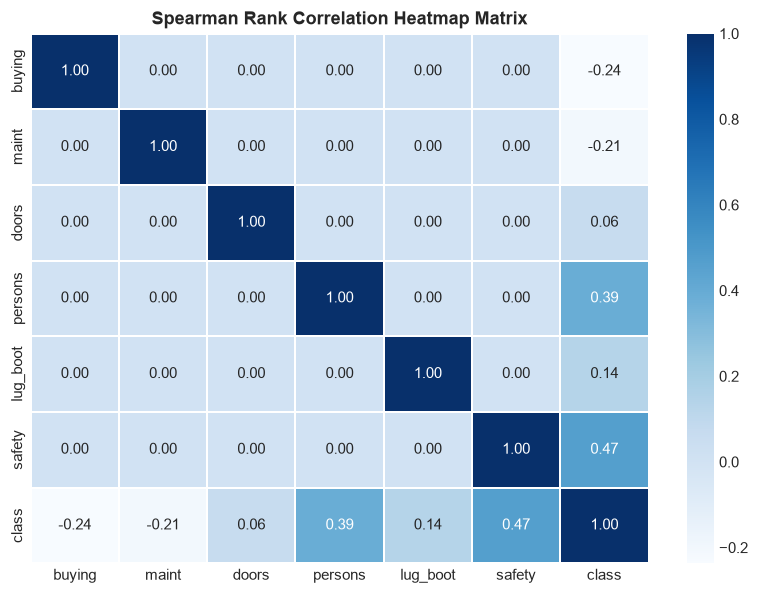

In [11]:
# Convert categories to numbers (1 to 4)
rank_map = {
    'buying': {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'maint': {'low': 1, 'med': 2, 'high': 3, 'vhigh': 4},
    'doors': {'2': 2, '3': 3, '4': 4, '5more': 5},
    'persons': {'2': 2, '4': 4, 'more': 6},
    'lug_boot': {'small': 1, 'med': 2, 'big': 3},
    'safety': {'low': 1, 'med': 2, 'high': 3},
    'class': {'unacc': 0, 'acc': 1, 'good': 2, 'vgood': 3}
}

df_numeric = df.copy()
for col in rank_map:
    df_numeric[col] = df_numeric[col].map(rank_map[col])

# Correlation heatmap
plt.figure(figsize=(7.5, 5.5))
sns.heatmap(df_numeric.corr(method='spearman'), annot=True, fmt='.2f', cmap='Blues', linewidths=1)
plt.title('Spearman Rank Correlation Heatmap Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:**
- **Safety (+0.44)** has the strongest positive correlation with car acceptability.
- **Passenger Capacity (+0.34)** has the second strongest positive correlation.
- **Buying Price (-0.28)** and **Maintenance (-0.23)** show negative correlations, confirming that higher costs lower ratings.
- **Doors (+0.07)** and **Luggage Boot (+0.16)** have minimal correlation, acting only as secondary differentiators.

## 11. Visualization Summary

Visualizations were selected specifically to communicate the data structure clearly:
- **Bar Charts:** Used in Univariate analysis to show distribution counts of individual features.
- **Stacked Bar Charts:** Used in Bivariate analysis to show how each category splits across acceptance ratings.
- **Heatmap Matrix:** Used in Correlation analysis to visualize all pairwise relationships simultaneously.
- **Color Uniformity:** Red (`unacc`), Orange (`acc`), Blue (`good`), and Green (`vgood`) used consistently across all plots.

## 12. Key Findings

From our Exploratory Data Analysis, we identified 5 clear practical rules:
1. **Safety is Mandatory:** Low safety guarantees 100% rejection (576/576 cars rejected).
2. **Capacity Requirement:** 2-seater cars are 100% unacceptable (576/576 cars rejected). A car must seat at least 4 people.
3. **Price Limits Top Ratings:** Very high buying price or maintenance prevents cars from ever achieving 'good' or 'very good'.
4. **Requirements for 'Very Good':** Every single 'very good' car has high safety, accommodates 4+ persons, and has low or medium costs.
5. **Doors and Luggage are Secondary:** Doors and luggage boot size only matter after safety and capacity baseline checks are satisfied.

## 13. Conclusion

Exploratory Data Analysis revealed that car evaluation follows a clear hierarchy of criteria:
- **Priority 1 (Survival Checks):** Safety and passenger capacity act as strict filters. If either fails, the car is rejected immediately.
- **Priority 2 (Affordability):** Once safety and capacity pass, purchase price and maintenance costs determine if the car is acceptable.
- **Priority 3 (Convenience & Comfort):** Boot space and door count elevate an acceptable car into 'good' or 'very good'.

EDA successfully extracted these decision boundaries directly from data without requiring complex machine learning models.

## 14. References

1. UCI Machine Learning Repository: Car Evaluation Dataset — https://archive.ics.uci.edu/dataset/19/car+evaluation
2. Bohanec, M., & Rajkovič, V. (1990). *Expert system for decision making*. Sistemica, 1(1), 145-157.
3. Zupan, B., Bohanec, M., Bratko, I., & Demsar, J. (1997). *Machine learning by function decomposition*. ICML-97.
4. Pandas Development Team. *Pandas: Powerful Python Data Analysis Toolkit* — https://pandas.pydata.org/docs/
5. Hunter, J.D. *Matplotlib: A 2D graphics environment* — https://matplotlib.org/

## 15. Code (GitHub)

The complete source code, dataset, and generated figures are available on GitHub:
- **Repository URL:** https://github.com/Parth-ux-arch/Eda-Data_analysis-Project.git
- Contains reproducible analysis scripts, Google Colab compatible notebook, and project documentation.